# Multi-Head Attention

Single-head attention lets every token mix information using **one** set of query, key,
and value projections, so it can focus on only one kind of relationship at a time.
**Multi-head attention** runs several attention operations in parallel. Each one, called a
*head*, uses its own slice of the projections, and the head outputs are concatenated.
Different heads can specialize: one may track local context, another long range
dependencies, another positional patterns.

The implementation is efficient. Instead of building `num_heads` separate layers, we use
one `d_out` wide projection and then reshape it into `num_heads` slices of size
`head_dim = d_out / num_heads`. All heads are then computed together with batched matrix
multiplication.

$$
\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\,W_O,
\qquad
\text{head}_i = \operatorname{softmax}\!\left(\frac{Q_i K_i^\top}{\sqrt{d_k}}\right) V_i
$$

Here $h$ is `num_heads`, $d_k$ is `head_dim`, and $W_O$ is the output projection `out_proj`.

### How the split works

A single `d_out = 4` projection is viewed as `num_heads = 2` heads of `head_dim = 2`:

```
d_out = 4   ->   [ h0_a  h0_b | h1_a  h1_b ]
                   \________/   \________/
                     head 0       head 1
```

Each head runs its own causal self attention on a `head_dim` wide slice, and the results
are joined back together at the end.

In [1]:
import torch
import torch.nn as nn

## The `__init__` method

| Component | Role |
| - | - |
| `assert d_out % num_heads == 0` | every head gets an equal slice, so `d_out` must divide evenly by the number of heads |
| `head_dim = d_out // num_heads` | the width of a single head |
| `W_query`, `W_key`, `W_value` | project the input to the full `d_out` width (all heads at once) |
| `out_proj` | mixes the concatenated head outputs back together |
| `dropout` | regularizes the attention weights during training |
| `register_buffer("mask", ...)` | the upper triangular causal mask, stored with the model but not trained |

Projecting to the full `d_out` and slicing afterward is what lets all heads share three
linear layers instead of `3 * num_heads` of them.

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0 ), \
        "d_out must be divisible by num_heads (number of heads)"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out) # Linear layer to combine head output
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
    def forward(self,x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)      # Shape:(b, num_tokens, d_out)
        queries = self.W_query(x) # Shape:(b, num_tokens, d_out)
        values = self.W_value(x)  # Shape:(b, num_tokens, d_out)

    # We implicitly split the matrix by adding a 'num_heads' dimension
    # Unroll last dim: (b, num_tokens, d_out) --> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

    # Transpose: (b, num_tokens, num_heads, head_dim) --> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

    # Compute scaled dot-product attention (aka self-attention) with a causal mask
        atten_scores = queries @ keys.transpose(2,3) # Dot-Product for each head

    # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    # Use the mask to fill attention scores
        atten_scores.masked_fill_(mask_bool, -torch.inf)

    # Find the attention weights 
        atten_weight = torch.softmax(atten_scores / keys.shape[-1] ** 0.5, dim=-1)
        atten_weight = self.dropout(atten_weight)

    # Shape: (b, num_tokens, num_heads, head_dim)
        context_vector = (atten_weight @ values).transpose(1,2)

    # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vector = context_vector.contiguous().view(b, num_tokens, self.d_out)
        context_vector = self.out_proj(context_vector) # optional projection

        return context_vector
    

## The `forward` pass, step by step

1. **Project** `x` into queries, keys, and values, each of shape `(b, tokens, d_out)`.
2. **Split into heads** with `view`, giving `(b, tokens, num_heads, head_dim)`, then
   `transpose(1, 2)` to `(b, num_heads, tokens, head_dim)` so each head is an independent
   `(tokens, head_dim)` matrix.
3. **Scaled scores** per head: `queries @ keys.transpose(2, 3)` produces
   `(b, num_heads, tokens, tokens)`.
4. **Causal mask**: `masked_fill_` sets the future positions to $-\infty$, so softmax gives
   them zero weight.
5. **Softmax and dropout** turn the scores into attention weights.
6. **Weighted values**: `atten_weight @ values`, then `transpose(1, 2)` back to
   `(b, tokens, num_heads, head_dim)`.
7. **Merge heads**: `contiguous().view(b, tokens, d_out)` concatenates the heads, and
   `out_proj` mixes them into the final output.

Shape walkthrough for `d_in = 3`, `d_out = 4`, `num_heads = 2` on a batch of `(2, 6, 3)`:

| Step | Shape |
| - | - |
| input `x` | `(2, 6, 3)` |
| Q, K, V after projection | `(2, 6, 4)` |
| after `view` into heads | `(2, 6, 2, 2)` |
| after `transpose(1, 2)` | `(2, 2, 6, 2)` |
| attention scores | `(2, 2, 6, 6)` |
| context per head | `(2, 2, 6, 2)` |
| merged output | `(2, 6, 4)` |

> **Why `.contiguous()`?** After a `transpose`, the tensor is no longer laid out
> contiguously in memory, so `view` would fail. `.contiguous()` makes a compact copy first,
> then `view` can reshape it safely.

## Running the layer

We reuse the six token toy input, stack it into a batch of two sequences, and pass it
through a two head layer with `d_out = 4`. The output has shape `(2, 6, 4)`: one context
vector per token, per sequence.

In [3]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89],   # Today
     [0.55, 0.87, 0.66],   # i
     [0.57, 0.85, 0.64],   # am
     [0.22, 0.58, 0.33],   # learning
     [0.77, 0.25, 0.10],   # deepseek
     [0.05, 0.80, 0.55]]   # course
)
batch = torch.stack((inputs, inputs), dim=0)   # (2, 6, 3)

torch.manual_seed(123)
context_length = batch.shape[1]
mha = MultiHeadAttention(d_in=3, d_out=4, context_length=context_length,
                         dropout=0.0, num_heads=2)
context_vectors = mha(batch)

print("input shape :", batch.shape)
print("output shape:", context_vectors.shape)   # -> (2, 6, 4)
print(context_vectors)

input shape : torch.Size([2, 6, 3])
output shape: torch.Size([2, 6, 4])
tensor([[[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]],

        [[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]]], grad_fn=<ViewBackward0>)


## Visualizing what each head attends to

Each head learns its own causal attention pattern. The heatmaps below show, for the first
sequence, how strongly each query token (row) attends to each key token (column) in each
head. The `x` cells are the masked future positions that receive zero weight.

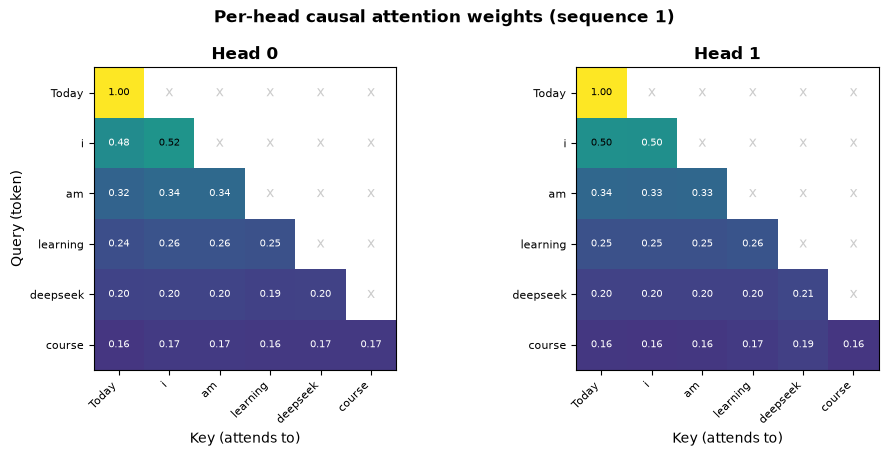

In [4]:
import matplotlib.pyplot as plt
import numpy as np

tokens = ["Today", "i", "am", "learning", "deepseek", "course"]

with torch.no_grad():
    b, n, _ = batch.shape
    q = mha.W_query(batch).view(b, n, mha.num_heads, mha.head_dim).transpose(1, 2)
    k = mha.W_key(batch).view(b, n, mha.num_heads, mha.head_dim).transpose(1, 2)
    scores = q @ k.transpose(2, 3)
    scores.masked_fill_(mha.mask.bool()[:n, :n], -torch.inf)
    weights = torch.softmax(scores / mha.head_dim ** 0.5, dim=-1)   # (b, heads, n, n)

w = weights[0].numpy()   # first sequence
fig, axes = plt.subplots(1, mha.num_heads, figsize=(5 * mha.num_heads, 4.6))
for h, ax in enumerate(axes):
    ax.imshow(np.where(w[h] == 0, np.nan, w[h]), cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f"Head {h}", fontweight="bold")
    ax.set_xlabel("Key (attends to)")
    if h == 0:
        ax.set_ylabel("Query (token)")
    for i in range(n):
        for j in range(n):
            if w[h, i, j] == 0:
                ax.text(j, i, "x", ha="center", va="center", color="#cccccc")
            else:
                ax.text(j, i, f"{w[h, i, j]:.2f}", ha="center", va="center",
                        color="white" if w[h, i, j] < 0.5 else "black", fontsize=7)
fig.suptitle("Per-head causal attention weights (sequence 1)", fontweight="bold")
fig.tight_layout()
plt.show()